In [2]:
# !nrnivmodl /home/wzl/LFPy/project/conductance_measurement/realistic_neuron/hippocampal_pyramidal_neuron/mod
from neuron import h
import plotly.graph_objects as go
import matplotlib.colors as mcolors
from neuron.units import ms, mV
import plotly.io as pio
from matplotlib import pyplot, cm
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import plotly
from neuron import clear_gui_callback
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from scipy.integrate import cumtrapz
from numpy.linalg import pinv, eig
import numpy as np
from multiprocessing import Pool
font2={'family':'Times New Roman',
'weight':'bold',
'size': 10}
# 自定义刻度标签显示格式

from neuron import h, gui

# 加载基础的 NEURON GUI 库
h.load_file("nrngui.hoc")

# 依次打开各个 HOC 文件
h.load_file("n128.hoc")               # 几何文件
h.load_file("axon_sections.hoc")      # 轴突部分
h.load_file("basal_dendrite.hoc")     # 基础树突
h.load_file("apical_dendrite.hoc")    # 顶端树突
h.load_file("apical_trunk.hoc")       # 顶端树干
h.load_file("radiatum.hoc")           # 放射区
h.load_file("init.hoc")               # 初始化设置
h.load_file("addgraph.hoc")           # 添加图形显示    

--No graphics will be displayed.


Check neuron_morph
	 Note: diam values less than 0.3um are set to 0.3um!
Diam was changed for: 0  points



1.0

In [2]:
for sec in h.allsec(): 

    for i in range(sec.n3d()): 
        h.pt3dchange(i, sec.diam3d(i)*0.5, sec=sec) 

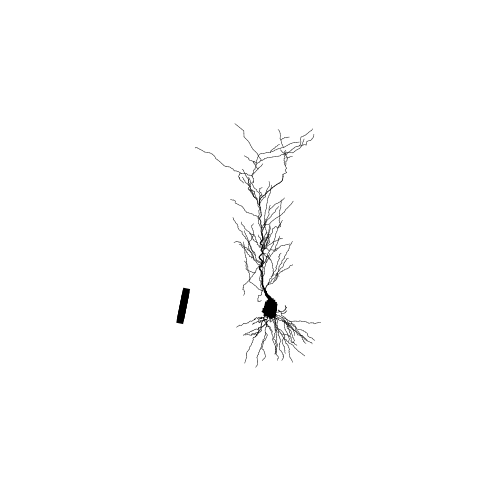

In [3]:
ps = h.PlotShape(False)  # False tells h.PlotShape not to use NEURON's gui
ps.show(0)
# ps.variable('v')
# ps.scale(minv, maxv)
ax = ps.plot(pyplot)

# # # 设置坐标轴范围
# ax.set_xlim([-300, 300])  # 设置x轴范围
# ax.set_ylim([0, 1400])  # 设置y轴范围
# ax.set_zlim([-600, 0])  # 设置z轴范围

# ps.view(-400,0, 0, 300, 0, 300, 100, 500)
ax.view_init(elev = 90, azim = 105.6)
# 关闭网格
ax.grid(False)
# 关闭坐标轴
ax.axis('off')

plt.savefig('hippocampus_pyramidal_morphology'+'.eps', format='eps')

pyplot.show()

In [2]:
def shapeplot(var_dend,
    figname = 'neurondendriticEPSP_fE1e-3', cmap = cm.jet,
    savefig = True, colorbarlabel='EPSP/mV', ticklabels=False,
    tickmin=0, tickmax=50, dt=10, setv=False, vmin=0., vmax=1.):

            
    h.scale_bar.diam = 0.1
    for sec in h.allsec():
        sec.v = 0
    for i in range(199):
        h.dend[i].v = var_dend[i]
    
    h.soma.v=0.

    v_vals = [seg.v for sec in h.allsec() for seg in sec]
    print(min(v_vals),max(v_vals))
    if setv:
        minv= vmin
        maxv = vmax
    else:
        minv= min(v_vals)
        maxv= max(v_vals)

            
    ps = h.PlotShape(False)  # False tells h.PlotShape not to use NEURON's gui
    ps.show(0)
    ps.variable('v')
    ps.scale(minv, maxv)
    ax = ps.plot(pyplot, cmap=cmap)

    # # # 设置坐标轴范围
    # ax.set_xlim([-300, 300])  # 设置x轴范围
    # ax.set_ylim([0, 1400])  # 设置y轴范围
    # ax.set_zlim([-600, 0])  # 设置z轴范围

    # ps.view(-400,0, 0, 300, 0, 300, 100, 500)
    ax.view_init(elev = 90, azim = 105.6)
    # 关闭网格
    ax.grid(False)
    # 关闭坐标轴
    ax.axis('off')
    
    # 保存为 EPS 格式
    if savefig:
        plt.savefig(figname+'.eps', format='eps')
    
    pyplot.show()
    
    
    
    # second figure
    ps = h.PlotShape(True)
    ps.show(0)
    ps.variable("v")
    ps.scale(minv, maxv)
    fig = ps.plot(plotly, cmap=cmap)
    ps.show(0)


    # Create a colormap function
    colormap = cm.ScalarMappable(cmap=cmap, 
    norm=mcolors.Normalize(vmin=0, vmax=1)).to_rgba

    # Map the normalized values to a Plotly colorscale as strings
    plotly_colorscale = [[v, f'rgb{tuple(int(255 * c) for c in colormap(v)[:3])}'] for v in np.linspace(0, 1, cmap.N)]

    # Create a separate scatter plot for the colorbar
    colorbar_trace = go.Scatter(
        x=[0],
        y=[0],
        mode='markers',
        marker=dict(
            colorscale=plotly_colorscale,
            cmin=minv,
            cmax=maxv,
            colorbar=dict(
                title=colorbarlabel,
                thickness=20  # Adjust the thickness of the colorbar
            ),
            showscale=True
        )
    )

    # Add the colorbar trace to the figure
    fig.add_trace(colorbar_trace)
    fig.update_xaxes(showticklabels=False, showgrid=True)
    fig.update_yaxes(showticklabels=False, showgrid=True)
    fig.update_layout(
        plot_bgcolor='rgba(0,0,0,0)'
    )

    # 创建自定义的颜色映射
    cmap = cmap
    colormap = cm.ScalarMappable(cmap=cmap, 
            norm=mcolors.Normalize(vmin=minv, vmax=maxv))

    # 创建一个新的图形和轴
    fig, ax = plt.subplots(figsize=(6, 1))

    # 绘制颜色条
    cbar = plt.colorbar(colormap, cax=ax, orientation='horizontal')
    cbar.set_label(colorbarlabel)
    if ticklabels:
        cbar.set_ticks(np.arange(tickmin, tickmax+dt, dt))
        cbar.set_ticklabels([f'{i}' for i in np.arange(tickmin, tickmax+dt, dt)])

    # 设置图的边界
    plt.tight_layout()

    if savefig:
        # 保存为 EPS 格式
        plt.savefig(figname+'colorbar'+'.eps', format='eps')

    # 显示图形（可选）
    plt.show()
    
    print(minv,maxv)

    

0.0746802999053033


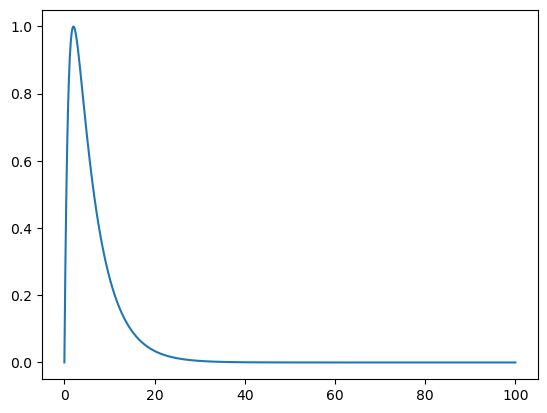

In [3]:
run_dt=0.1
syn_tau1 = 1.
syn_tau2 = 5.
fE = 1e-3
t=np.arange(0,100+run_dt,run_dt)
NE = ((syn_tau1/syn_tau2)**(syn_tau1/(syn_tau2-syn_tau1))-(syn_tau1/syn_tau2)**(syn_tau2/(syn_tau2-syn_tau1)))**-1
uE = NE*(np.exp(-t/syn_tau2)-np.exp(-t/syn_tau1))
plt.plot(t,uE)
ground_truth = np.mean(uE)
print(ground_truth)

0.006292570251838361 0.7491151259432196
0.0 0.7491151259432196


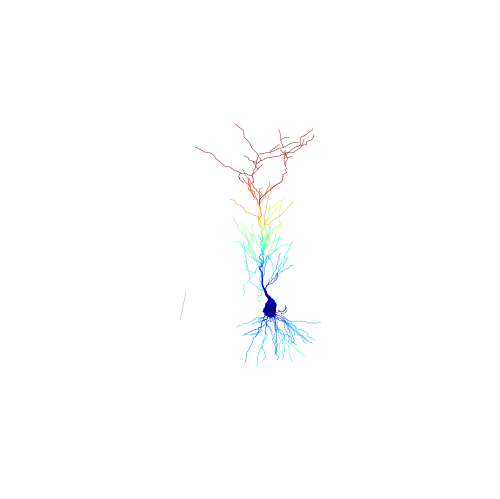

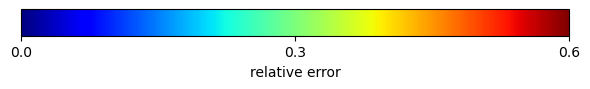

0.0 0.6


In [8]:
estimated_mean_cond_dend= np.loadtxt("estimated_mean_cond_passive_dend199_fE6e4.txt")
estimated_mean_cond_us_dend = estimated_mean_cond_dend[:,0]
estimated_mean_cond_trad_dend = estimated_mean_cond_dend[:,1]

fE = 6e-4

var_dend = np.abs(estimated_mean_cond_trad_dend - ground_truth*fE)/(ground_truth*fE)
print(np.min(var_dend),np.max(var_dend))
shapeplot(var_dend, figname = 'passive_local_trad_fE6e4', 
        savefig = True, colorbarlabel='relative error', ticklabels = True, 
        tickmin = 0, tickmax = 0.6, dt = 0.3, cmap = cm.jet, setv = True, vmin=0., vmax=0.6)

0.00021345870789980217 0.16993961358414153
0.0 0.16993961358414153


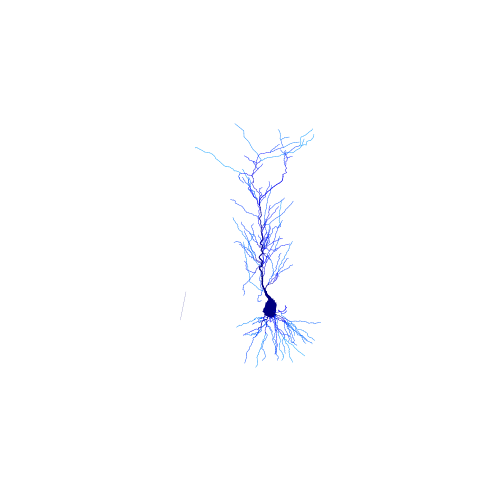

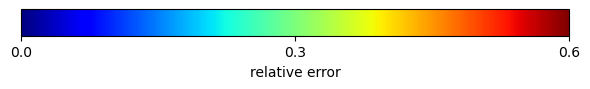

0.0 0.6


In [9]:
estimated_mean_cond_dend= np.loadtxt("estimated_mean_cond_passive_dend199_fE6e4.txt")
estimated_mean_cond_us_dend = estimated_mean_cond_dend[:,0]
estimated_mean_cond_trad_dend = estimated_mean_cond_dend[:,1]

fE = 6e-4

var_dend = np.abs(estimated_mean_cond_us_dend - ground_truth*fE)/(ground_truth*fE)
print(np.min(var_dend),np.max(var_dend))
shapeplot(var_dend, figname = 'passive_local_us_fE6e4', 
        savefig = True, colorbarlabel='relative error', ticklabels = True, 
        tickmin = 0, tickmax = 0.6, dt = 0.3, cmap = cm.jet, setv = True, vmin=0., vmax=0.6)

0.0006274632063380921 28.544468181206
0.0 28.544468181206


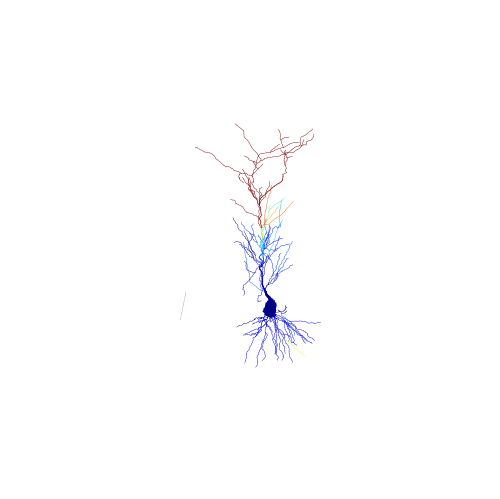

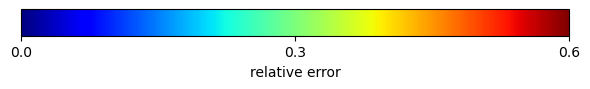

0.0 0.6


In [10]:
estimated_mean_cond_dend= np.loadtxt("estimated_mean_cond_active_dend199_fE6e4.txt")
estimated_mean_cond_us_dend = estimated_mean_cond_dend[:,0]
estimated_mean_cond_trad_dend = estimated_mean_cond_dend[:,1]

fE = 6e-4

var_dend = np.abs(estimated_mean_cond_us_dend - ground_truth*fE)/(ground_truth*fE)
print(np.min(var_dend),np.max(var_dend))
shapeplot(var_dend, figname = 'active_local_us_fE6e4', 
        savefig = True, colorbarlabel='relative error', ticklabels = True, 
        tickmin = 0, tickmax = 0.6, dt = 0.3, cmap = cm.jet, setv = True, vmin=0., vmax=0.6)

0.008470247420603622 0.851588269122531
0.0 0.851588269122531


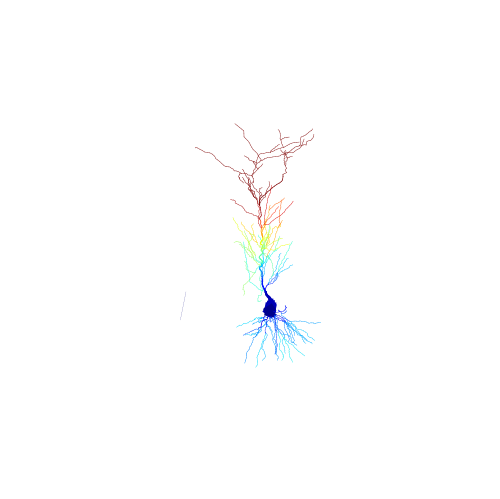

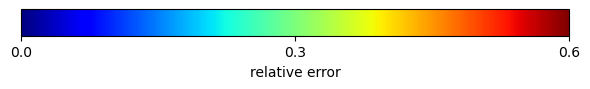

0.0 0.6


In [11]:
estimated_mean_cond_dend= np.loadtxt("estimated_mean_cond_active_dend199_fE6e4.txt")
estimated_mean_cond_us_dend = estimated_mean_cond_dend[:,0]
estimated_mean_cond_trad_dend = estimated_mean_cond_dend[:,1]

fE = 6e-4

var_dend = np.abs(estimated_mean_cond_trad_dend - ground_truth*fE)/(ground_truth*fE)
print(np.min(var_dend),np.max(var_dend))
shapeplot(var_dend, figname = 'active_local_trad_fE6e4', 
        savefig = True, colorbarlabel='relative error', ticklabels = True, 
        tickmin = 0, tickmax = 0.6, dt = 0.3, cmap = cm.jet, setv = True, vmin=0., vmax=0.6)

0.004585636895891509 0.7746419123326739
0.0 0.7746419123326739


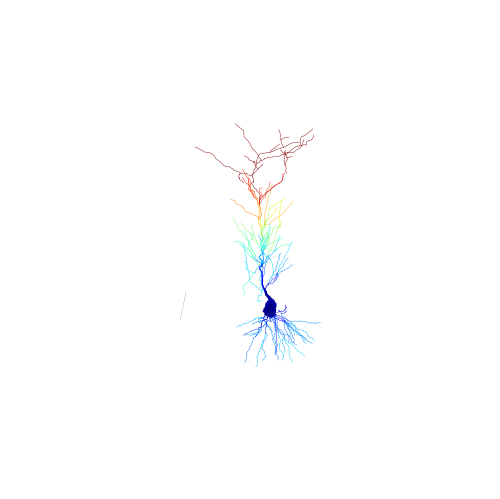

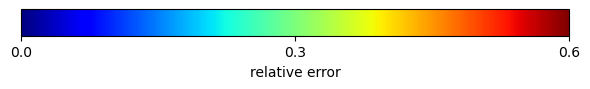

0.0 0.6


In [12]:
estimated_mean_cond_dend= np.loadtxt("estimated_mean_cond_active_dend199_fI6e4.txt")
estimated_mean_cond_us_dend = estimated_mean_cond_dend[:,0]
estimated_mean_cond_trad_dend = estimated_mean_cond_dend[:,1]

fE = 6e-4

var_dend = np.abs(estimated_mean_cond_trad_dend - ground_truth*fE)/(ground_truth*fE)
print(np.min(var_dend),np.max(var_dend))
shapeplot(var_dend, figname = 'active_local_trad_fI6e4', 
        savefig = True, colorbarlabel='relative error', ticklabels = True, 
        tickmin = 0, tickmax = 0.6, dt = 0.3, cmap = cm.jet, setv = True, vmin=0., vmax=0.6)

4.3037817400975066e-05 0.42561453732160653
0.0 0.42561453732160653


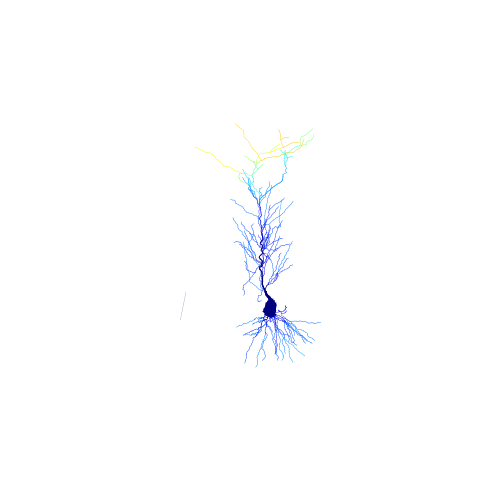

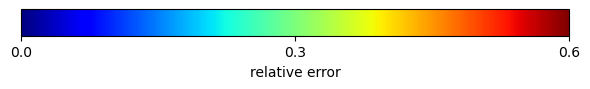

0.0 0.6


In [13]:
estimated_mean_cond_dend= np.loadtxt("estimated_mean_cond_active_dend199_fI6e4.txt")
estimated_mean_cond_us_dend = estimated_mean_cond_dend[:,0]
estimated_mean_cond_trad_dend = estimated_mean_cond_dend[:,1]

fE = 6e-4

var_dend = np.abs(estimated_mean_cond_us_dend - ground_truth*fE)/(ground_truth*fE)
print(np.min(var_dend),np.max(var_dend))
shapeplot(var_dend, figname = 'active_local_us_fI6e4', 
        savefig = True, colorbarlabel='relative error', ticklabels = True, 
        tickmin = 0, tickmax = 0.6, dt = 0.3, cmap = cm.jet, setv = True, vmin=0., vmax=0.6)

0.0039169548670206856 0.6843955482747095
0.0 0.6843955482747095


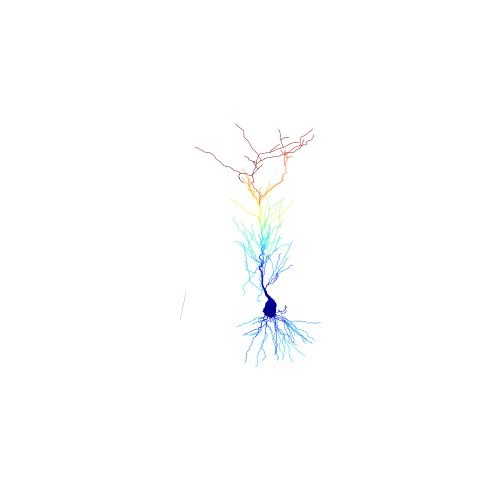

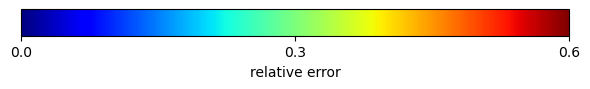

0.0 0.6


In [14]:
estimated_mean_cond_dend= np.loadtxt("estimated_mean_cond_passive_dend199_fI6e4.txt")
estimated_mean_cond_us_dend = estimated_mean_cond_dend[:,0]
estimated_mean_cond_trad_dend = estimated_mean_cond_dend[:,1]

fE = 6e-4

var_dend = np.abs(estimated_mean_cond_trad_dend - ground_truth*fE)/(ground_truth*fE)
print(np.min(var_dend),np.max(var_dend))
shapeplot(var_dend, figname = 'passive_local_trad_fI6e4', 
        savefig = True, colorbarlabel='relative error', ticklabels = True, 
        tickmin = 0, tickmax = 0.6, dt = 0.3, cmap = cm.jet, setv = True, vmin=0., vmax=0.6)

7.828925668407282e-05 0.221023781075272
0.0 0.221023781075272


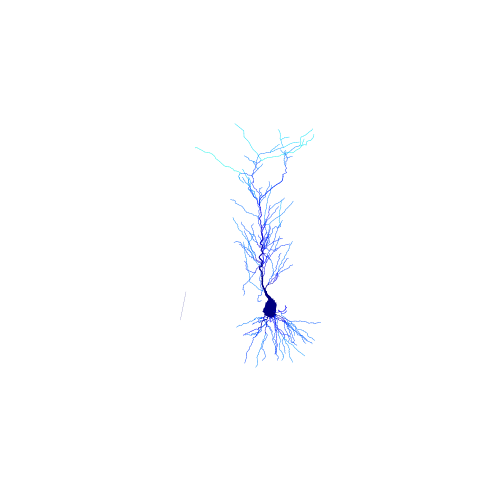

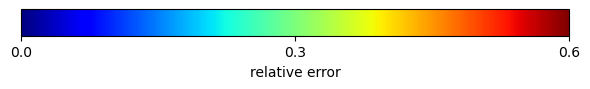

0.0 0.6


In [15]:
estimated_mean_cond_dend= np.loadtxt("estimated_mean_cond_passive_dend199_fI6e4.txt")
estimated_mean_cond_us_dend = estimated_mean_cond_dend[:,0]
estimated_mean_cond_trad_dend = estimated_mean_cond_dend[:,1]

fE = 6e-4

var_dend = np.abs(estimated_mean_cond_us_dend - ground_truth*fE)/(ground_truth*fE)
print(np.min(var_dend),np.max(var_dend))
shapeplot(var_dend, figname = 'passive_local_us_fI6e4', 
        savefig = True, colorbarlabel='relative error', ticklabels = True, 
        tickmin = 0, tickmax = 0.6, dt = 0.3, cmap = cm.jet, setv = True, vmin=0., vmax=0.6)

0.0 1.1362113646201557


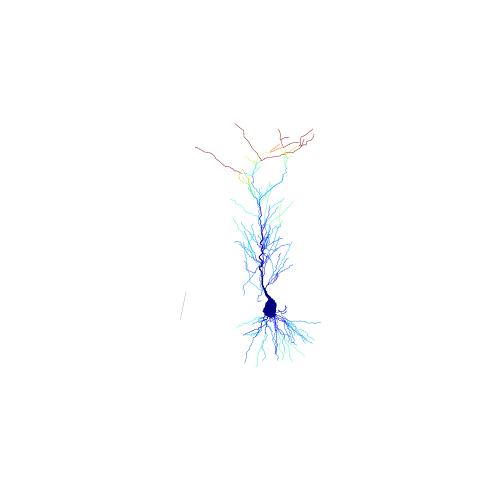

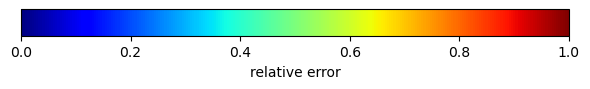

0.0 1.0
0.0 0.0872952351467969


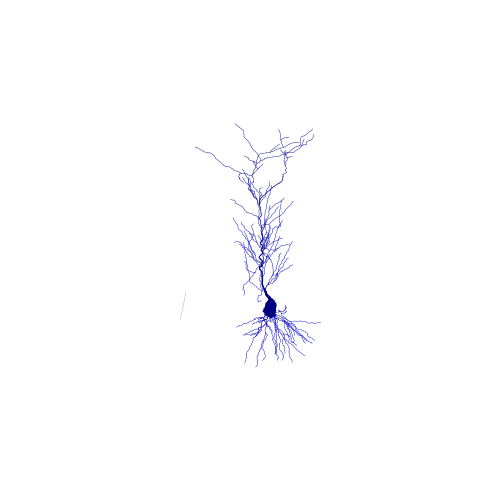

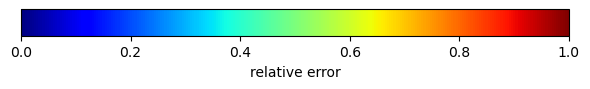

0.0 1.0


In [16]:
estimated_lambdas_dend= np.loadtxt("est_time_const_passive_dend199_fI6e4.txt")
estimated_lambdas_dend_rise = -1./estimated_lambdas_dend[:,0]
estimated_lambdas_dend_decay = -1./estimated_lambdas_dend[:,1]


truth_rise = 1.0
var_dend_rise = np.abs(estimated_lambdas_dend_rise - truth_rise)/truth_rise

truth_decay = 5.0
var_dend_decay = np.abs(estimated_lambdas_dend_decay - truth_decay)/truth_decay
shapeplot(var_dend_rise,  
        figname = 'passive_rise_fI6e3', cmap = cm.jet,
        savefig = True, colorbarlabel='relative error',ticklabels=False,
        tickmin=0, tickmax=1.0, dt=0.5,  setv=True, vmin=0., vmax=1.)
 
shapeplot(var_dend_decay,  
        figname = 'passive_decay_fI6e3', cmap = cm.jet,
        savefig = True, colorbarlabel='relative error',ticklabels=False,
        tickmin=0, tickmax=1.0, dt=0.5,  setv=True, vmin=0., vmax=1.)

0.0 8.03186466384147


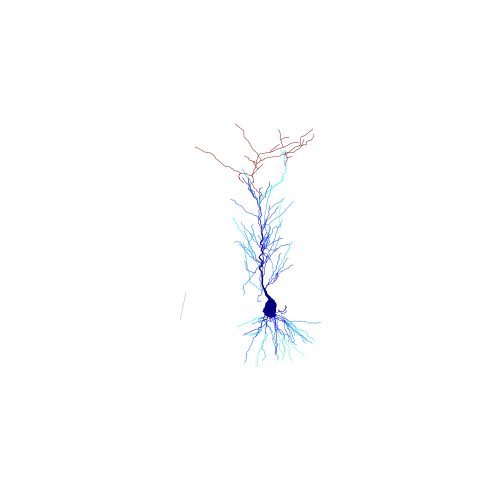

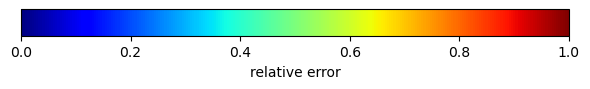

0.0 1.0
0.0 2652.5853411266385


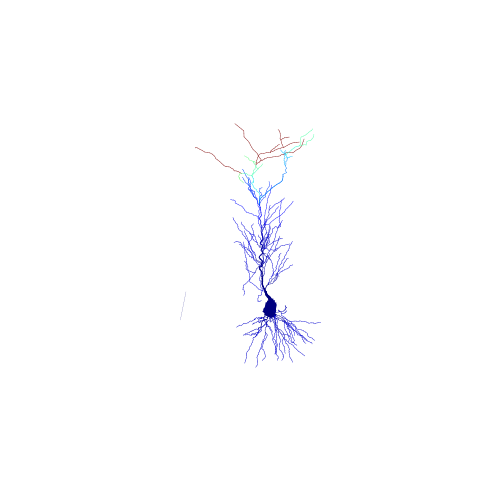

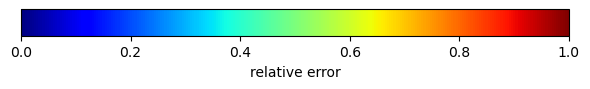

0.0 1.0


In [17]:
estimated_lambdas_dend= np.loadtxt("est_time_const_active_dend199_fI6e4.txt")
estimated_lambdas_dend_rise = -1./estimated_lambdas_dend[:,0]
estimated_lambdas_dend_decay = -1./estimated_lambdas_dend[:,1]


truth_rise = 1.0
var_dend_rise = np.abs(estimated_lambdas_dend_rise - truth_rise)/truth_rise

truth_decay = 5.0
var_dend_decay = np.abs(estimated_lambdas_dend_decay - truth_decay)/truth_decay
shapeplot(var_dend_rise,  
        figname = 'active_rise_fI6e3', cmap = cm.jet,
        savefig = True, colorbarlabel='relative error',ticklabels=False,
        tickmin=0, tickmax=1.0, dt=0.5,  setv=True, vmin=0., vmax=1.)
 
shapeplot(var_dend_decay,  
        figname = 'active_decay_fI6e3', cmap = cm.jet,
        savefig = True, colorbarlabel='relative error',ticklabels=False,
        tickmin=0, tickmax=1.0, dt=0.5,  setv=True, vmin=0., vmax=1.)

0.0 14.167659093059036


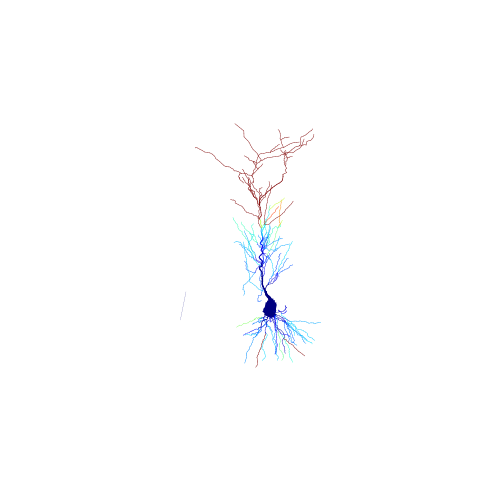

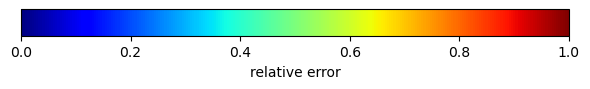

0.0 1.0
0.0 2.033531818611807


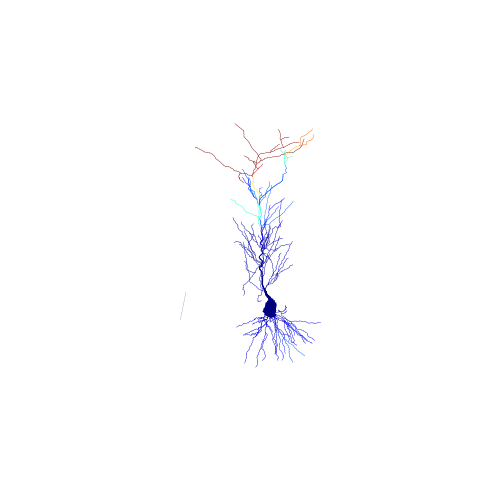

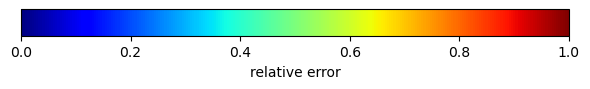

0.0 1.0


In [18]:
estimated_lambdas_dend= np.loadtxt("est_time_const_active_dend199_fE6e4.txt")
estimated_lambdas_dend_rise = -1./estimated_lambdas_dend[:,0]
estimated_lambdas_dend_decay = -1./estimated_lambdas_dend[:,1]


truth_rise = 1.0
var_dend_rise = np.abs(estimated_lambdas_dend_rise - truth_rise)/truth_rise

truth_decay = 5.0
var_dend_decay = np.abs(estimated_lambdas_dend_decay - truth_decay)/truth_decay
shapeplot(var_dend_rise,  
        figname = 'active_rise_fE6e3', cmap = cm.jet,
        savefig = True, colorbarlabel='relative error',ticklabels=False,
        tickmin=0, tickmax=1.0, dt=0.5,  setv=True, vmin=0., vmax=1.)
 
shapeplot(var_dend_decay,  
        figname = 'active_decay_fE6e3', cmap = cm.jet,
        savefig = True, colorbarlabel='relative error',ticklabels=False,
        tickmin=0, tickmax=1.0, dt=0.5,  setv=True, vmin=0., vmax=1.)

0.0 1.1362113465831571


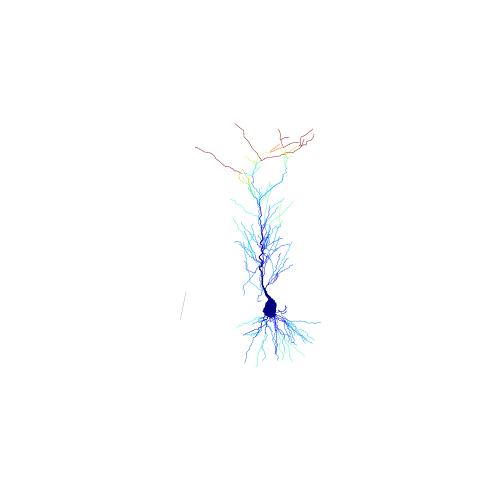

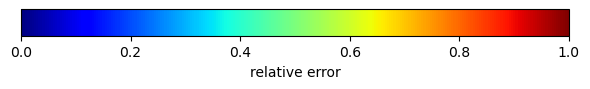

0.0 1.0
0.0 0.0872952351449566


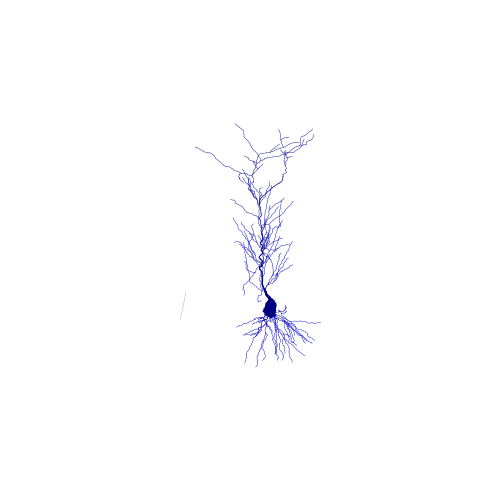

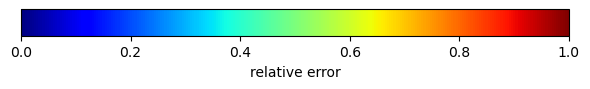

0.0 1.0


In [19]:
estimated_lambdas_dend= np.loadtxt("est_time_const_passive_dend199_fE6e4.txt")
estimated_lambdas_dend_rise = -1./estimated_lambdas_dend[:,0]
estimated_lambdas_dend_decay = -1./estimated_lambdas_dend[:,1]


truth_rise = 1.0
var_dend_rise = np.abs(estimated_lambdas_dend_rise - truth_rise)/truth_rise

truth_decay = 5.0
var_dend_decay = np.abs(estimated_lambdas_dend_decay - truth_decay)/truth_decay
shapeplot(var_dend_rise,  
        figname = 'passive_rise_fE6e3', cmap = cm.jet,
        savefig = True, colorbarlabel='relative error',ticklabels=False,
        tickmin=0, tickmax=1.0, dt=0.5,  setv=True, vmin=0., vmax=1.)
 
shapeplot(var_dend_decay,  
        figname = 'passive_decay_fE6e3', cmap = cm.jet,
        savefig = True, colorbarlabel='relative error',ticklabels=False,
        tickmin=0, tickmax=1.0, dt=0.5,  setv=True, vmin=0., vmax=1.)

In [23]:

x = np.linspace(0,40,10)
y = np.exp(-x) + np.exp(-2*x) + 1.
# Calculate integrals
iy1 = cumtrapz(y, x, initial=0)
iy2 = cumtrapz(iy1, x, initial=0)

print(np.shape(iy1))

# Get exponentials lambdas
Y = np.column_stack((iy1, iy2,  x**2, x, np.ones_like(x)))
print(np.shape(Y))
# A = pinv(Y) @ y

# lambdas = eig(np.array([[A[0], A[1]], [1, 0]]))[0]
# # print("Lambdas:", lambdas)

# # Get exponentials multipliers
# X = np.column_stack((np.ones_like(x), np.exp(lambdas[0] * x), np.exp(lambdas[1] * x)))
# P = pinv(X) @ y
# print("Multipliers:", P)

(10,)
(10, 5)


/tmp/ipykernel_9841/2718853973.py:4: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  iy1 = cumtrapz(y, x, initial=0)
/tmp/ipykernel_9841/2718853973.py:5: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  iy2 = cumtrapz(iy1, x, initial=0)


In [25]:
print(Y[:,0])
print(iy1)

[ 0.          8.91529231 13.3864467  17.83120126 22.27564934 26.72009383
 31.16453828 35.60898272 40.05342716 44.49787161]
[ 0.          8.91529231 13.3864467  17.83120126 22.27564934 26.72009383
 31.16453828 35.60898272 40.05342716 44.49787161]


In [17]:
import numpy as np
from scipy.integrate import cumtrapz

# 定义数据
x = np.linspace(0, 10, 3)
y = x

# 计算累积积分
integrated_y = cumtrapz(y, x, initial=0)

# 打印结果
print(integrated_y)


[ 0.  12.5 50. ]


/tmp/ipykernel_9841/4014338396.py:9: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  integrated_y = cumtrapz(y, x, initial=0)


In [18]:
print(y)
print(integrated_y)

[ 0.  5. 10.]
[ 0.  12.5 50. ]
